# Importaciones Necesarias:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lectura de los datos

In [2]:
datos = pd.read_csv('student_dropout_dataset_v3.csv')
drop_cols = ["Student_ID", "Dropout"]

X = datos.drop(columns=drop_cols)
y = datos['Dropout']

# Resumen de los datos

In [3]:
resumenEntrada = X.describe()
resumenSalida = y.describe()
print(resumenEntrada)
print(resumenSalida)

               Age  Family_Income  Study_Hours_per_Day  Attendance_Rate  \
count  10000.00000    9500.000000          9500.000000      10000.00000   
mean      21.02606   38377.247474             4.014592         81.73683   
std        2.13981   20496.232179             1.295450          8.22093   
min       17.00000   25000.000000             0.500000         38.20000   
25%       19.50000   25000.000000             3.160000         76.40000   
50%       21.00000   29740.500000             4.000000         81.80000   
75%       22.50000   44520.000000             4.870000         87.30000   
max       29.60000  316601.000000             8.980000        100.00000   

       Assignment_Delay_Days  Travel_Time_Minutes  Stress_Index           GPA  \
count           10000.000000          10000.00000   9500.000000  10000.000000   
mean                1.799700             30.17926      5.507147      2.308440   
std                 1.344307             11.91887      1.765951      1.061717   


# Gráficas para mostrar datos:

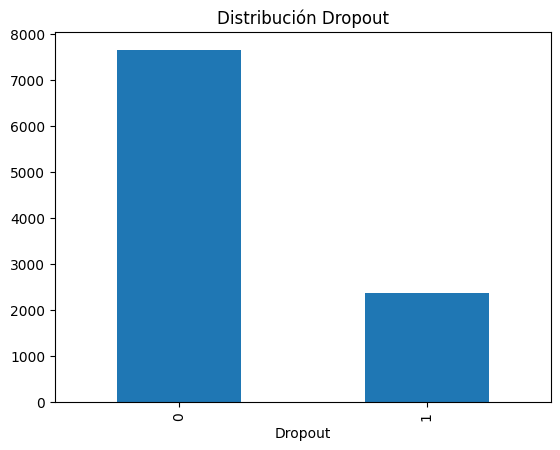

In [4]:
# Gráfica que muestra la distribución de dropout

y.value_counts().plot(kind="bar")
plt.title("Distribución Dropout")
plt.show()

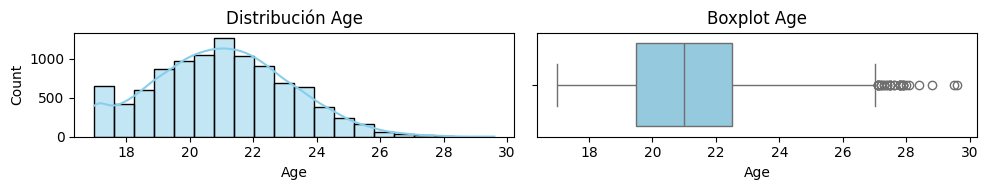

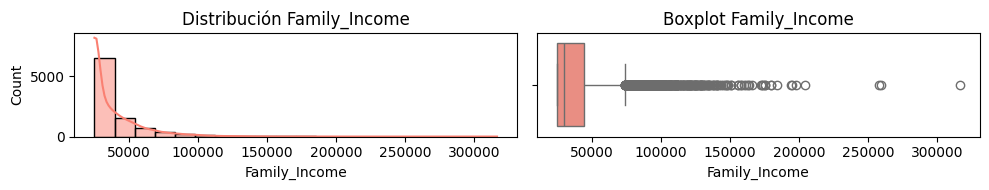

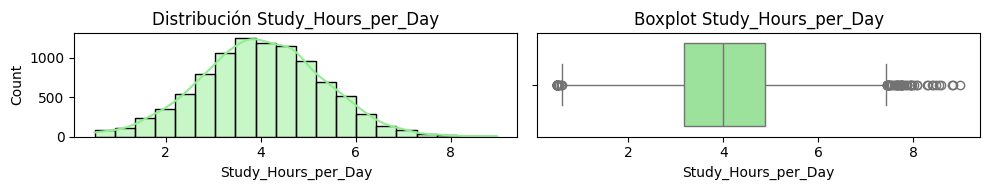

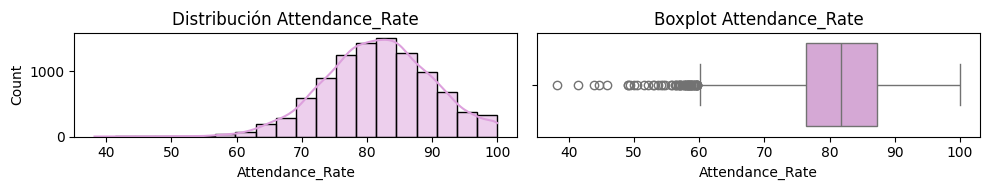

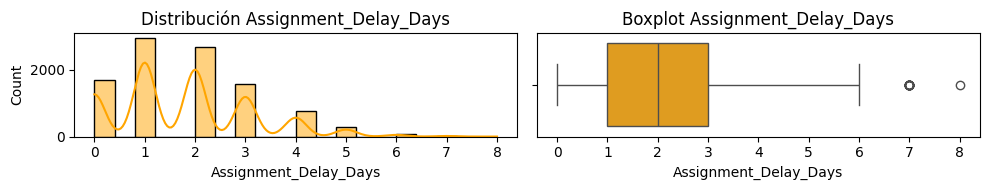

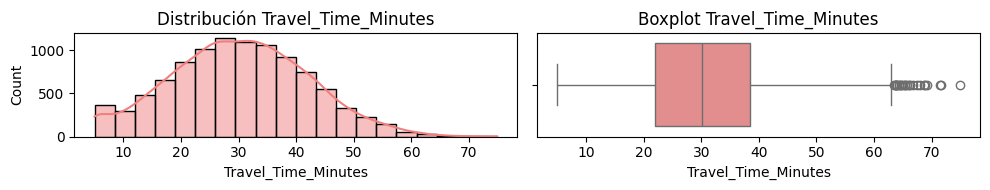

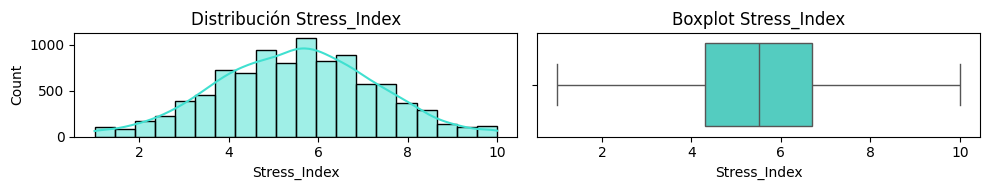

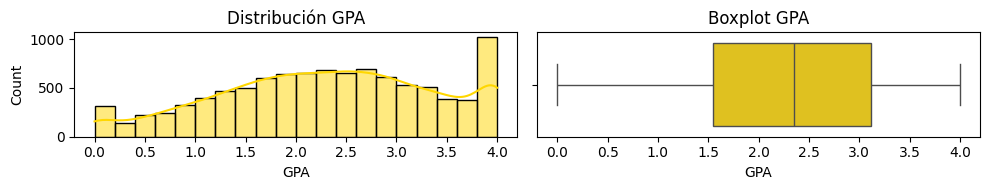

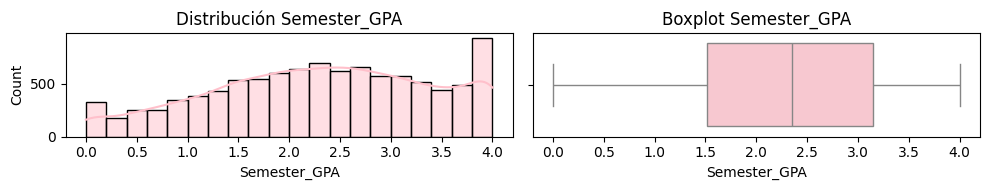

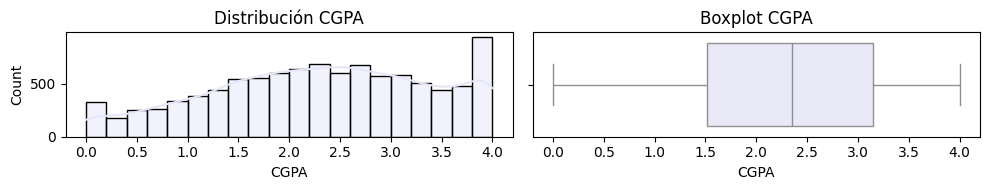

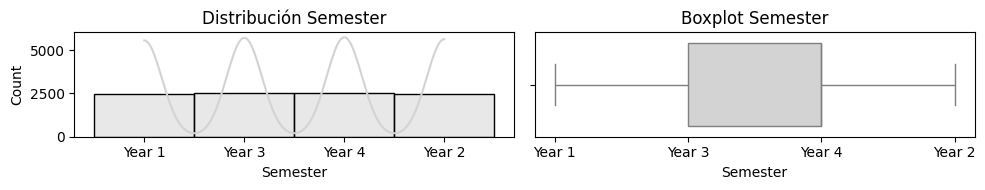

In [5]:
num_cols = ["Age", "Family_Income", "Study_Hours_per_Day", "Attendance_Rate", 
            "Assignment_Delay_Days", "Travel_Time_Minutes", "Stress_Index", 
            "GPA", "Semester_GPA", "CGPA", "Semester"]

colors = ["skyblue", "salmon", "lightgreen", "plum", "orange", 
          "lightcoral", "turquoise", "gold", "pink", "lavender", "lightgray"]

for col, color in zip(num_cols, colors):
    fig, axes = plt.subplots(1, 2, figsize=(10, 2))
    
    sns.histplot(data=X, x=col, bins=20, kde=True, color=color, ax=axes[0])
    axes[0].set_title(f"Distribución {col}")
    
    sns.boxplot(data=X, x=col, color=color, ax=axes[1])
    axes[1].set_title(f"Boxplot {col}")
    
    plt.tight_layout()
    plt.show()

# División de datos en conjuntos de entrenamiento , validación y test.

In [10]:
from sklearn.model_selection import train_test_split

# test es el 10% de los ejemplos, entranmiento es 80% y validación el resto.
X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size = 0.10, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_resto, y_resto, test_size = 0.20, stratify=y_resto, random_state=42)


# Detección y tratamiento de outliers:

In [11]:
# Importamos la clase TransformerMixin
from sklearn.base import TransformerMixin

# Creamos la clase de detección y tratamiento de Outliers
class OutlierDetecion_treatment_IQR(TransformerMixin):

    # Constructor de la clase
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    # Método fit
    def fit(self, X, y=None):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        if self.columns is None:
            # Si no se determinan variables en el constructor si tratan todas
            self.columns = X.select_dtypes(include="number").columns
        self.stats = X[self.columns].describe()
        self.median = X[self.columns].median()

        # Devolvemos el propio objeto modificado
        return self

    # Método transform
    def transform(self, X):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        # Creamos una copia del DataFrame X para no perder los datos originales
        Xaux = X.copy()


        # Se comprueba qué elementos están por encima y por debajo de dichos límites (máscaras de booleanos)
        Q1 = self.stats.loc['25%']   
        Q3 = self.stats.loc['75%']
        IQRs = Q3 - Q1
        limiteInf = Q1 - self.k * IQRs
        limiteSup = Q3 + self.k * IQRs  
        menores = Xaux[self.columns] < limiteInf
        mayores = Xaux[self.columns] > limiteSup

        # Se recorren las variables para detectar outliers y tratarlos (sustituir por la mediana de la variable)
        for c in self.columns:
            # obtenemos la lista de booleanos correspondientes a si los valores de los ejemplos son outliers o no para la variable c
#             indices = <RELLENAR>
            indices = np.logical_or(menores[c],mayores[c])
            # Si hay outliers
            # <RELLENAR>
            if indices.any():
                Xaux.loc[indices,c] = self.median[c]
                # Los sustituimos por la mediana
                # <RELLENAR>
        # Se devuelve el DataFrame modificado
        return Xaux
    
    # Método para asignar los valores de los híper-parámetros y que, de este modo, 
        # podamos aplicar GridSearchCV sobre un objeto de esta clase
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
    def get_params(self, deep=True):
        # Devolvemos los valores de los híper-parámetros del método de preparación de datos
        return {"k": self.k}

In [12]:
out_IQR = OutlierDetecion_treatment_IQR(k=3)
out_IQR.fit(X_train)

# Test y Train sin Outliers

X_train_IQR = out_IQR.transform(X_train)
X_test_IQR = out_IQR.transform(X_test)

print(X_train_IQR.shape)
print(X_train.shape)

(7200, 17)
(7200, 17)


# Imputar valores perdidos en categoricas y numéricas:

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

columnas_numericas = list(X_train_IQR.select_dtypes(include="number").columns)
columnas_categoricas = list(X_train_IQR.select_dtypes(include="object").columns)

print(columnas_numericas)
print(columnas_categoricas)

# Aqui he utilizado un tipo de imputacion ( luego cuando tengamos el knn hecho se prueban diferentes para ver cual va mejor etc etc...)
imputer = ColumnTransformer(transformers=[("imp_numericas", SimpleImputer(strategy="mean"), columnas_numericas), 
                                          ("imp_categoricas", SimpleImputer(strategy="most_frequent"), columnas_categoricas)], remainder="passthrough")

imputer.fit(X_train_IQR)
X_train_imputado = imputer.transform(X_train_IQR)
X_test_imputado = imputer.transform(X_test_IQR)
cols_orden = columnas_numericas + columnas_categoricas
X_train_imputado = pd.DataFrame(X_train_imputado, columns=cols_orden, index=X_train_IQR.index)
X_test_imputado  = pd.DataFrame(X_test_imputado,  columns=cols_orden, index=X_test_IQR.index)

['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


C:\Users\alano\AppData\Local\Temp\ipykernel_2148\1694956938.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = list(X_train_IQR.select_dtypes(include="object").columns)


# Pasar valores categoricos a numéricos:

In [14]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
# De momento solo pongo un tipo de encoder para probar!

encoder = ColumnTransformer(transformers=[("ohe", OneHotEncoder(),columnas_categoricas),],remainder="passthrough")
encoder.fit(X_train_imputado)
X_train_enc = encoder.transform(X_train_imputado)
X_test_enc  = encoder.transform(X_test_imputado)
print(X_train_enc)


[[1.0 0.0 1.0 ... 1.95 1.96 1.97]
 [1.0 0.0 0.0 ... 0.89 0.98 0.98]
 [0.0 1.0 0.0 ... 2.45 2.56 2.56]
 ...
 [0.0 1.0 0.0 ... 3.29 3.58 3.66]
 [0.0 1.0 0.0 ... 4.0 4.0 4.0]
 [1.0 0.0 0.0 ... 3.3 3.52 3.52]]


## Métricas de rendimiento

In [15]:
X_val_IQR = out_IQR.transform(X_val)
#Imputamos valores perdidos
X_val_imputado = imputer.transform(X_val_IQR)
X_val_imputado = pd.DataFrame(X_val_imputado, columns=cols_orden, index=X_val_IQR.index)
#Codificamos valores categoricas
X_val_enc = encoder.transform(X_val_imputado)

X_train_final =  X_train_enc
X_val_final = X_val_enc
X_test_final = X_test_enc

print(X_train_final.shape, X_val_final.shape, X_test_final.shape)

(7200, 31) (1800, 31) (1000, 31)


In [16]:
from sklearn.neighbors import KNeighborsClassifier

modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_train_final, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report

y_val_pred = modelo.predict(X_val_final)
matriz_confusion = confusion_matrix(y_val, y_val_pred)

print("Matriz de confusión:")
print(matriz_confusion)
print()
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, pos_label=1))
print("Recall:", recall_score(y_val, y_val_pred, pos_label=1))
print("F1:", f1_score(y_val, y_val_pred, pos_label=1))
print()
print(classification_report(y_val, y_val_pred))

Matriz de confusión:
[[1278   98]
 [ 354   70]]

Accuracy: 0.7488888888888889
Balanced accuracy: 0.5469367046950416
Precision: 0.4166666666666667
Recall: 0.1650943396226415
F1: 0.23648648648648649

              precision    recall  f1-score   support

           0       0.78      0.93      0.85      1376
           1       0.42      0.17      0.24       424

    accuracy                           0.75      1800
   macro avg       0.60      0.55      0.54      1800
weighted avg       0.70      0.75      0.71      1800



In [18]:
from sklearn.metrics import roc_curve,roc_auc_score,precision_recall_curve,auc

y_val_proba = modelo.predict_proba(X_val_final)[:, 1]

fpr, tpr, umbrales_roc = roc_curve(y_val, y_val_proba, pos_label=1)
roc_auc = roc_auc_score(y_val, y_val_proba)

precision_curve, recall_curve, umbrales_pr = precision_recall_curve(y_val, y_val_proba, pos_label=1)
pr_auc = auc(recall_curve, precision_curve)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.5924404892496709
PR-AUC: 0.33874077437951133


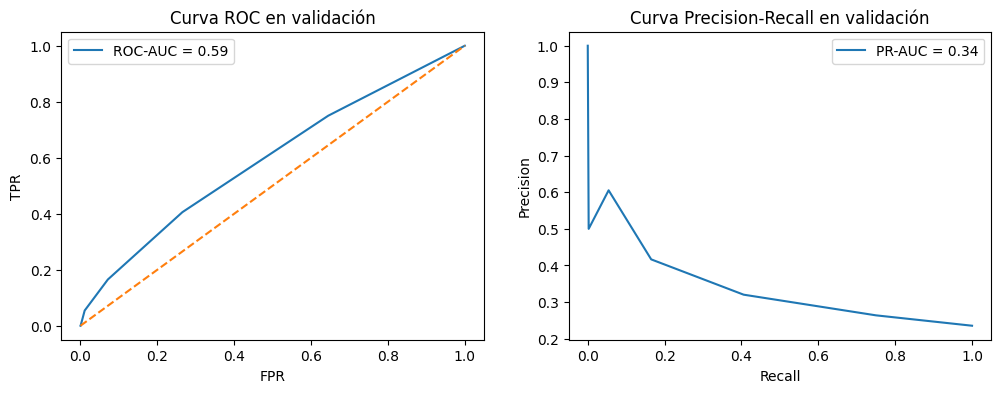

In [30]:
fig,ax = plt.subplots(1,2,figsize = (12,4))

ax[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.2f}")
ax[0].plot([0, 1], [0, 1], linestyle="--")
ax[0].set_xlabel("FPR")
ax[0].set_ylabel("TPR")
ax[0].set_title("Curva ROC en validación")
ax[0].legend()

ax[1].plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.2f}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Curva Precision-Recall en validación")
ax[1].legend()
plt.show()

In [32]:
umbrales = np.arange(0.10, 1.00, 0.05)

resultados_umbral = []

for umbral in umbrales:
    y_val_umbral = (y_val_proba >= umbral).astype(int)
    acc = accuracy_score(y_val, y_val_umbral)
    bal_acc = balanced_accuracy_score(y_val, y_val_umbral)
    prec = precision_score(y_val, y_val_umbral, pos_label=1)
    rec = recall_score(y_val, y_val_umbral, pos_label=1)
    f1 = f1_score(y_val, y_val_umbral, pos_label=1)
    resultados_umbral.append([umbral, acc, bal_acc, prec, rec, f1])

tabla_umbral = pd.DataFrame(resultados_umbral, columns=["umbral", "accuracy", "balanced_accuracy", "precision", "recall", "f1"])
tabla_umbral

,umbral,accuracy,balanced_accuracy,precision,recall,f1
0,0.10,0.448333,0.552689,0.263900,0.750000,0.390424
1,0.15,0.448333,0.552689,0.263900,0.750000,0.390424
2,0.20,0.657222,0.570199,0.320298,0.405660,0.357960
3,0.25,0.657222,0.570199,0.320298,0.405660,0.357960
4,0.30,0.657222,0.570199,0.320298,0.405660,0.357960
5,0.35,0.657222,0.570199,0.320298,0.405660,0.357960
6,0.40,0.748889,0.546937,0.416667,0.165094,0.236486
7,0.45,0.748889,0.546937,0.416667,0.165094,0.236486
8,0.50,0.748889,0.546937,0.416667,0.165094,0.236486
9,0.55,0.748889,0.546937,0.416667,0.165094,0.236486


In [36]:
mejor_f1 = tabla_umbral.loc[tabla_umbral["f1"].idxmax()]
umbral_optimo = mejor_f1["umbral"]

print("Mejor fila según F1:")
print(mejor_f1)
print()
print("Umbral óptimo:", umbral_optimo)

Mejor fila según F1:
umbral               0.100000
accuracy             0.448333
balanced_accuracy    0.552689
precision            0.263900
recall               0.750000
f1                   0.390424
Name: 0, dtype: float64

Umbral óptimo: 0.1


In [40]:
y_test_proba = modelo.predict_proba(X_test_final)[:,1]
y_test_pred = (y_test_proba >= umbral_optimo).astype(int)

matriz_confusion_test = confusion_matrix(y_test,y_test_pred)

print("Matriz de confusión en test:")
print(matriz_confusion_test)
print()
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))

precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba, pos_label=1)
pr_auc_test = auc(recall_test, precision_test)
print("PR-AUC:", pr_auc_test)

Matriz de confusión en test:
[[255 510]
 [ 70 165]]

Accuracy: 0.42
Balanced accuracy: 0.5177304964539007
Precision: 0.24444444444444444
Recall: 0.7021276595744681
F1: 0.3626373626373626
ROC-AUC: 0.5505492977332778
PR-AUC: 0.2943762528494122


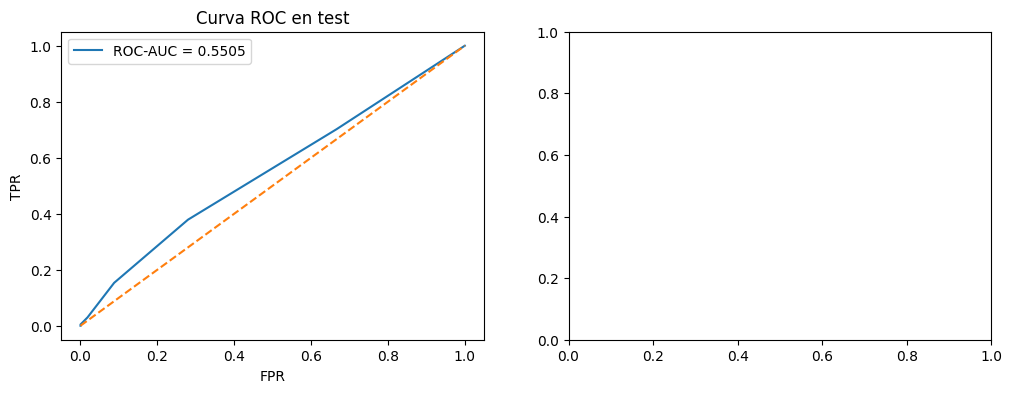

In [ ]:
fig,ax = plt.subplots(1,2,figsize = (12,4))

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba, pos_label=1)

ax[0].plot(fpr_test, tpr_test, label=f"ROC-AUC = {roc_auc_score(y_test, y_test_proba):.4f}")
ax[0].plot([0, 1], [0, 1], linestyle="--")
ax[0].set_xlabel("FPR")
ax[0].set_ylabel("TPR")
ax[0].set_title("Curva ROC en test")
ax[0].legend()

precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba, pos_label=1)

ax[1].plot(recall_test, precision_test, label=f"PR-AUC = {auc(recall_test, precision_test):.4f}")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Curva Precision-Recall en test")
ax[1].legend()
plt.show()